### Numerical Solution of ODEs Using RK4

In this notebook, we implement the classical 4th-order Runge–Kutta (RK4) method to numerically solve ordinary differential equations (ODEs).

We illustrate the method using two practical examples commonly seen in biomedical sciences:

1. Logistic growth model (population / tumor growth)

2. One-compartment pharmacokinetic (PK) model with first-order elimination

We use only NumPy, avoiding black-box solvers to clearly expose the mechanics of RK4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Define a modular function for RK4

In [2]:
def rk4(f, y0, t):
    """
    Solve an ODE using the classical 4th-order Runge-Kutta method.

    Parameters
    ----------
    f : callable
        Right-hand side of the ODE: dy/dt = f(t, y)
    y0 : float or np.ndarray
        Initial condition
    t : np.ndarray
        Time grid (assumed equally spaced)

    Returns
    -------
    y : np.ndarray
        Numerical solution evaluated at time points t
    """
    y = np.zeros((len(t), np.size(y0)))
    y[0] = y0

    h = t[1] - t[0] # assuming equal spaced t

    for i in range(len(t) - 1):
        # if uneven t time grid
        # h = t[i+1] - t[i]
        
        ti = t[i]
        yi = y[i]

        k1 = f(ti, yi)
        k2 = f(ti + h/2, yi + h/2 * k1)
        k3 = f(ti + h/2, yi + h/2 * k2)
        k4 = f(ti + h, yi + h * k3)

        y[i+1] = yi + h/6 * (k1 + 2*k2 + 2*k3 + k4)

    return y.squeeze()

    # if uneven t time grid, consider returning t as well 
    # return y.squeeze(), t

### Example 1: Logistic Growth Model 

$$\frac{dN}{dt} = rN(1-\frac{N}{K})$$

where: 

- $r$ = intrinsic growth rate
- $K$ = carrying capacity

It has an analytical solution: 

$$ N(t) = \frac{K}{1 + \left(\frac{K - N_0}{N_0}\right)e^{-rt}} $$

Define the right-hand side with some parameter values.

In [3]:
# Logistic growth parameters
# to-do: play with the values!
r = 0.5
K = 100
N0 = 10

# define `f` 
def logistic_rhs(t, N):
    return r * N * (1 - N / K)

Time Grid and RK4 Solution

In [4]:
t = np.linspace(0, 20, 200)
# t = np.linspace(0, 20, 20)

N_rk4 = rk4(logistic_rhs, # f, defined 
            N0, t)
# y values at t

Compare with analytical solution 

In [5]:
N_true = K / (1 + ((K - N0) / N0) * np.exp(-r * t))

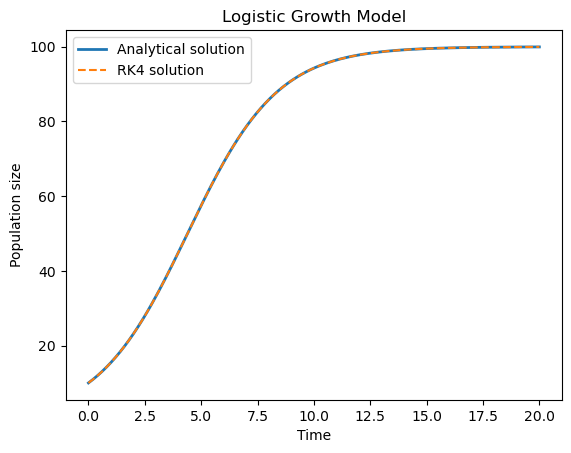

In [6]:
## Visualization 

plt.figure()
plt.plot(t, N_true, label="Analytical solution", linewidth=2)
plt.plot(t, N_rk4, "--", label="RK4 solution")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Logistic Growth Model")
plt.legend()
plt.show()

### Example 2: One-compartmental PK Model 

We consider a one-compartment pharmacokinetic (PK) model with IV bolus dosing and first-order elimination:

$$\frac{dC(t)}{dt} = -kC(t)$$ 

where: 

- $C(t)$ = drug concentration

- $k$ = $\frac{CL}{V}$ = elimination rate constant

- $CL$ = clearance 

- $V$ = volume of distribution 

It also has an analytical solution: 

$$C(t) = C_0 e^{-kt}$$

Parameter values and define right-hand side function. 

In [7]:
# PK parameters
CL = 5.0   # clearance (L/hour)
V = 50.0   # volume of distribution (L)
k = CL / V # play around with this 

C0 = 10.0  # initial concentration (mg/L)

# define `f` 
def pk_rhs(t, C):
    return -k * C


Time grid and RK4 solution 

In [8]:
t_pk = np.linspace(0, 24, 200)
# try: 
# t_pk = np.linspace(0, 24, 24)

C_rk4 = rk4(pk_rhs, # `f` 
            C0, t_pk)

Compare with truth

In [9]:
C_true = C0 * np.exp(-k * t_pk)

Visualize comparison 

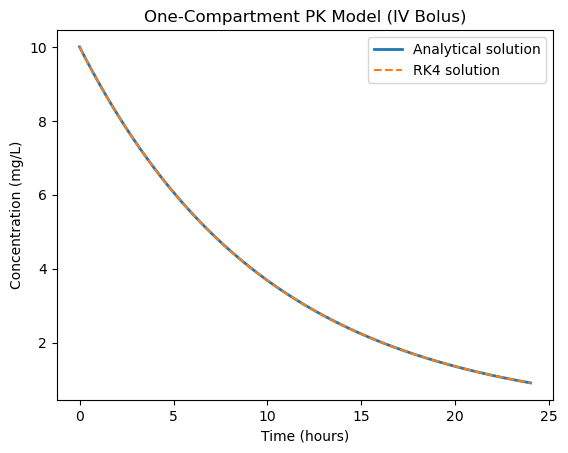

In [10]:
plt.figure()
plt.plot(t_pk, C_true, label="Analytical solution", linewidth=2)
plt.plot(t_pk, C_rk4, "--", label="RK4 solution")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.title("One-Compartment PK Model (IV Bolus)")
plt.legend()
plt.show()

### Solving ODEs with SciPy

Next, we use built-in ODE solvers provided in the `scipy` package and revisit the two examples above. 

In [2]:
from scipy.integrate import solve_ivp

In [3]:
?solve_ivp

`solve_ivp` is the standard SciPy interface for solving initial value problems (IVPs):

$$\frac{dy}{dt} = f(t,y), \quad y(t_0) = y_0$$

Key advantages:

- Automatic step-size control

- Multiple solver choices (RK45, RK23, BDF, etc.)

- Efficient and robust for real-world models

By default, solve_ivp uses RK45 (adaptive Runge–Kutta).

### Example 1 again: Logistic Growth Model 

In [12]:
## Define time span and evaluation grids
t_span = (0, 20)
t_eval = np.linspace(0, 20, 200) # play with this? 

## Solve using SciPy
sol_logistic = solve_ivp(
    logistic_rhs, # `f` 
    t_span,
    y0=[N0],
    t_eval=t_eval,
    method="RK45" # change this 
)

N_scipy = sol_logistic.y[0]

Compare with truth (again, re-using the analytical solution defined above)

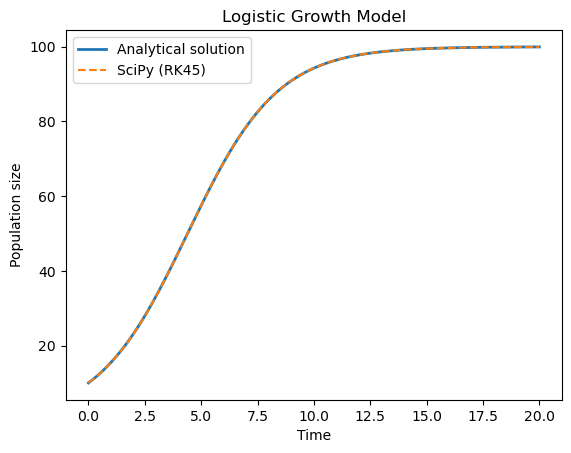

In [13]:
plt.figure()
plt.plot(t_eval, N_true, label="Analytical solution", linewidth=2)
plt.plot(t_eval, N_scipy, "--", label="SciPy (RK45)")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Logistic Growth Model")
plt.legend()
plt.show()


### Example 2 again: One-compartmental PK model 

In [14]:
## time span and grid points
t_span_pk = (0, 24)
t_eval_pk = np.linspace(0, 24, 200)

## solving using SciPy 
sol_pk = solve_ivp(
    pk_rhs,
    t_span_pk,
    y0=[C0],
    t_eval=t_eval_pk,
    method="RK45" # could change this
)

C_scipy = sol_pk.y[0]


Compare with truth (again, available from above)

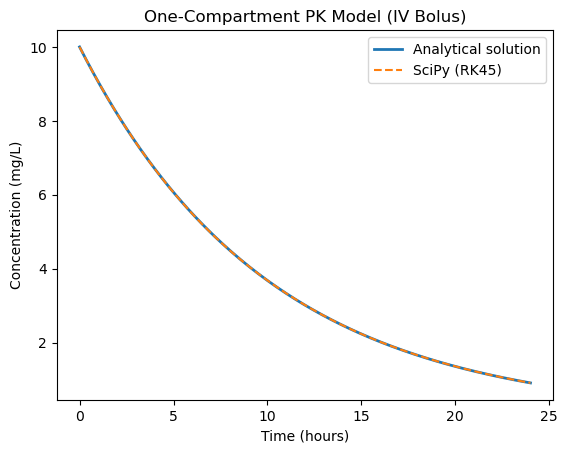

In [15]:
plt.figure()
plt.plot(t_eval_pk, C_true, label="Analytical solution", linewidth=2)
plt.plot(t_eval_pk, C_scipy, "--", label="SciPy (RK45)")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.title("One-Compartment PK Model (IV Bolus)")
plt.legend()
plt.show()

## Example 3 (extended): Predator-prey model (non-linear, ODE system)

The predator–prey model (aka the Lotka–Volterra system) describes interactions between a prey population $x(t)$ 
and a predator population $y(t)$: 

$$\frac{dx}{dt} = \alpha x - \beta x y$$
$$\frac{dy}{dt} = \delta x y - \gamma y$$

Where: 

- $\alpha$ = prey birth rate
- $\beta$ = predation rate
- $\gamma$ = predator death rate
- $\delta$  = predator reproduction rate


This system generally **does not have a closed-form solution**

Define parameter values and initial conditions

In [16]:
# Predator-prey parameters
# can play around with parameter values!
alpha = 1.0    # prey growth rate
beta = 0.1     # predation rate
gamma = 1.5    # predator death rate
delta = 0.075  # predator reproduction rate

# Initial populations
x0 = 10.0   # prey
y0 = 5.0    # predator


Define right hand side of the ODE system

In [17]:
def predator_prey_rhs(t, z):
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]
## note: you can return multiple objects (as a list or tuple)

Time span and numerical solution in `scipy`

In [18]:
t_span_pp = (0, 30)
t_eval_pp = np.linspace(0, 30, 500)

sol_pp = solve_ivp(
    predator_prey_rhs,
    t_span_pp,
    y0=[x0, y0],
    t_eval=t_eval_pp,
    method="RK45"
)

x = sol_pp.y[0] # input and output are both 2-d, so need to take out 1st and 2nd entries in the solution
y = sol_pp.y[1]


Visualize the solution: time series 

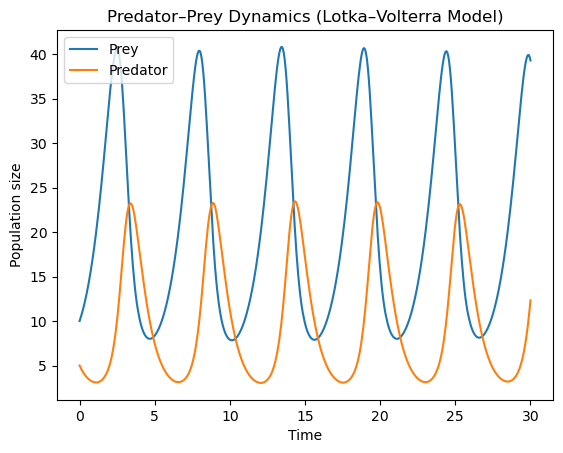

In [19]:
plt.figure()
plt.plot(t_eval_pp, x, label="Prey")
plt.plot(t_eval_pp, y, label="Predator")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Predator–Prey Dynamics (Lotka–Volterra Model)")
plt.legend()
plt.show()


Phase plane (on x,y plane instead of time)

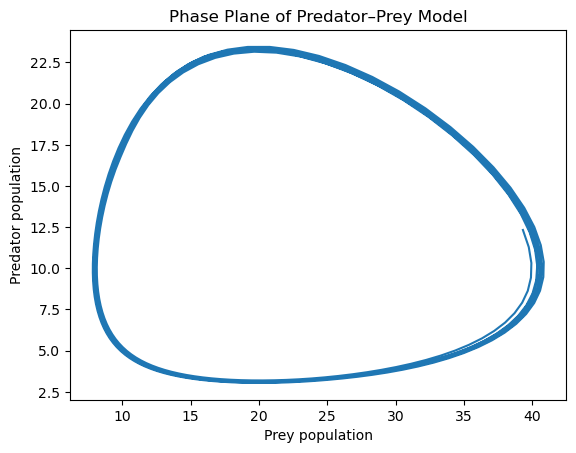

In [20]:
plt.figure()
plt.plot(x, y)
plt.xlabel("Prey population")
plt.ylabel("Predator population")
plt.title("Phase Plane of Predator–Prey Model")
plt.show()


### Take-home practice: adapt the hand-written `rk4` function to solve the predator-prey model? 